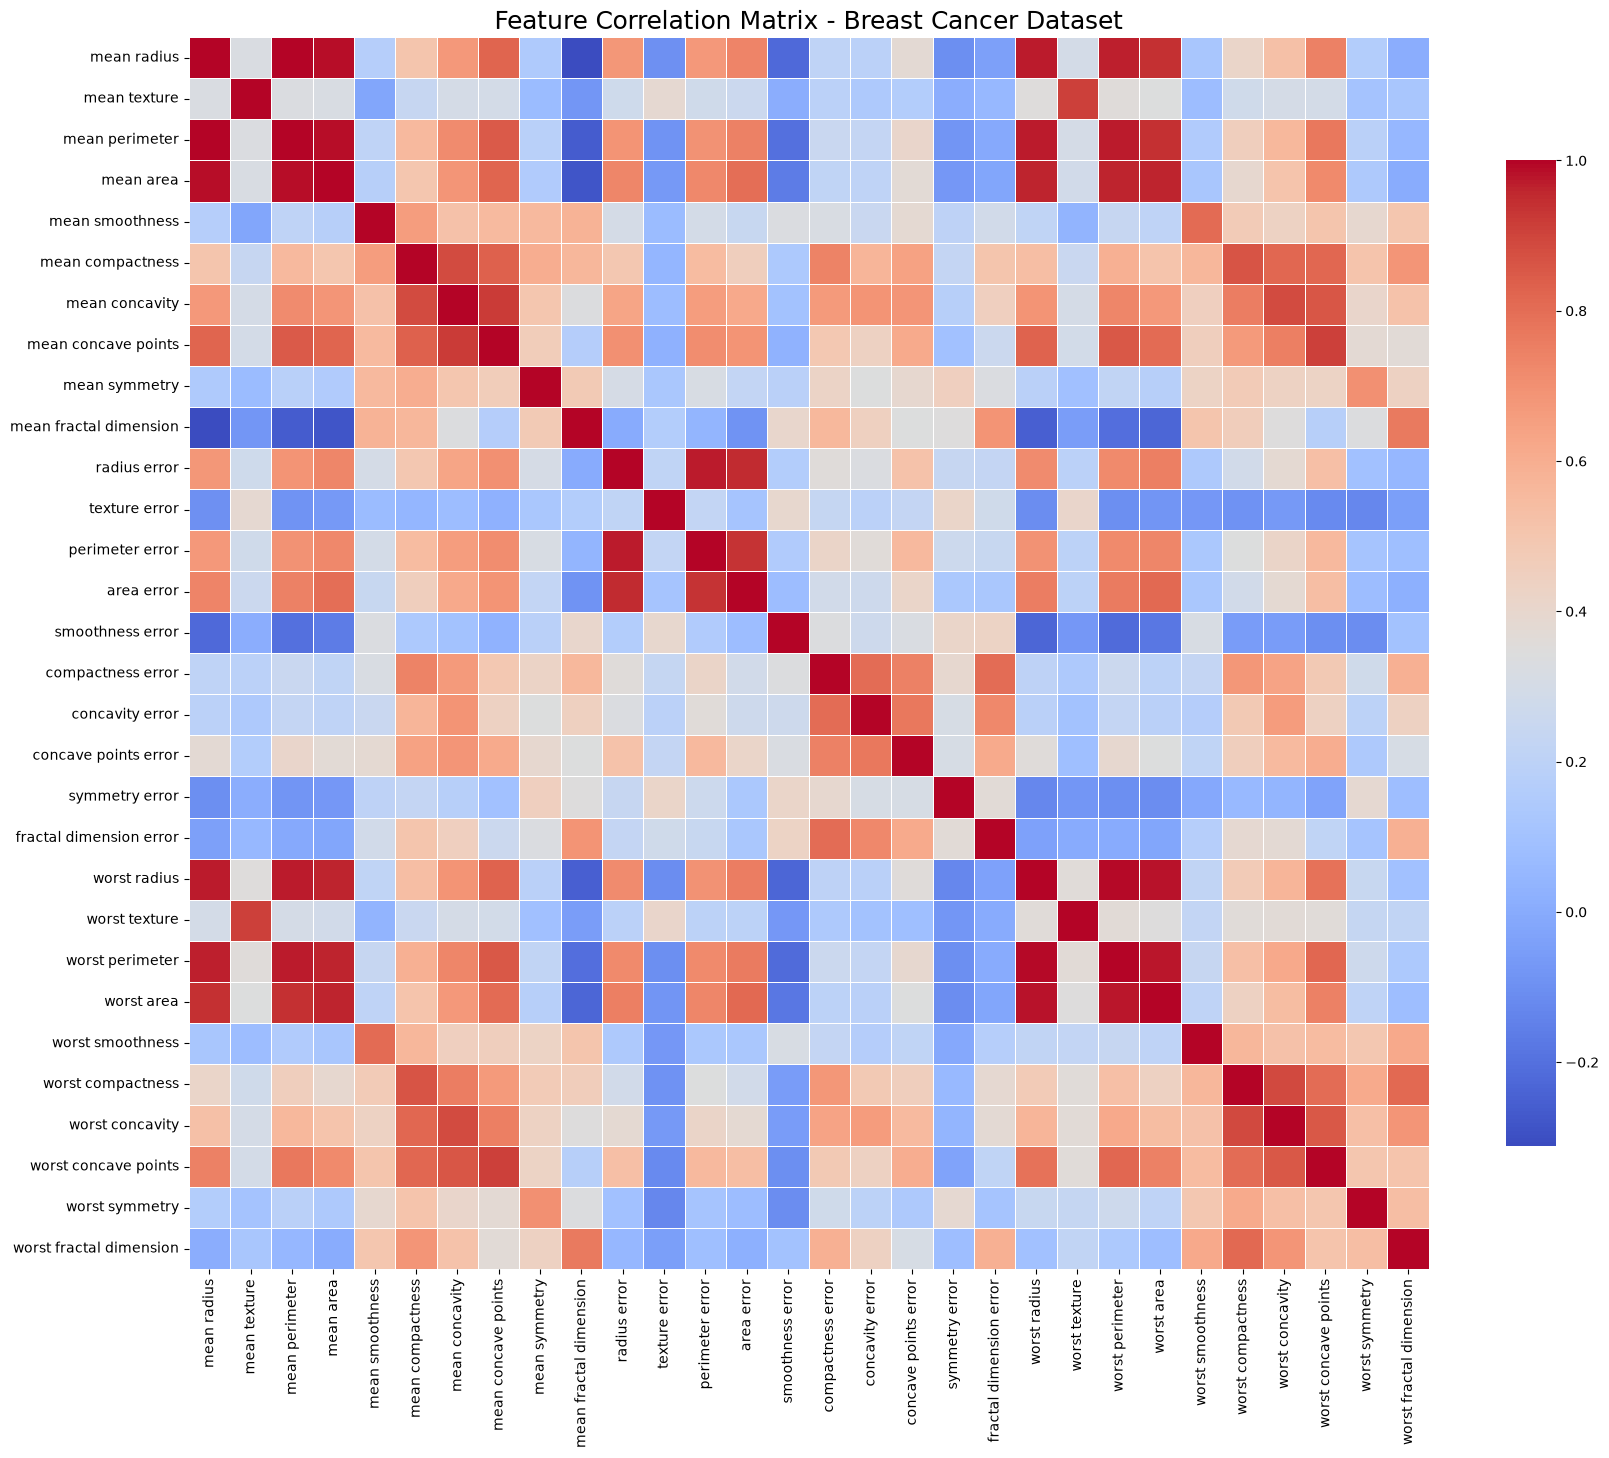

Heatmap saved successfully to reports/correlation_heatmap.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
import os

# 1. Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# 2. Compute the correlation matrix
corr_matrix = df.corr()

# 3. Create the heatmap
plt.figure(figsize=(20, 16)) 
sns.heatmap(
    corr_matrix, 
    annot=False,       # Set to True if you want numbers (will be crowded)
    cmap='coolwarm',   # Red for positive, Blue for negative
    fmt=".2f", 
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)
plt.title('Feature Correlation Matrix - Breast Cancer Dataset', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# 4. Save the image to my reports folder
# Create the folder if it doesn't exist
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/correlation_heatmap.png', dpi=300, bbox_inches='tight')

# 5. Show the plot
plt.show()

print("Heatmap saved successfully to reports/correlation_heatmap.png")

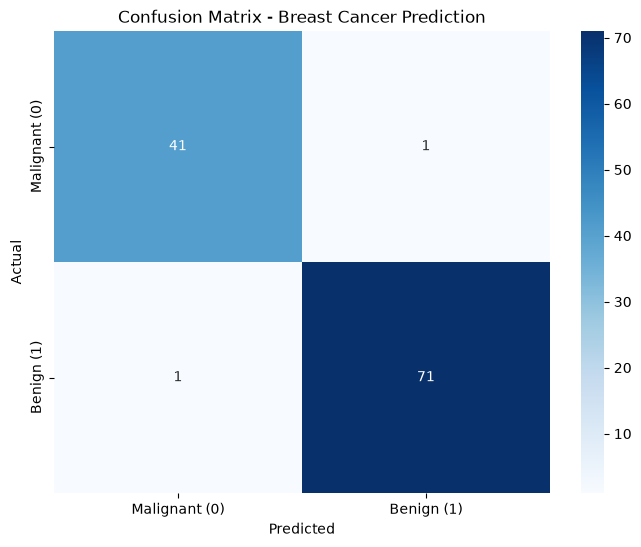

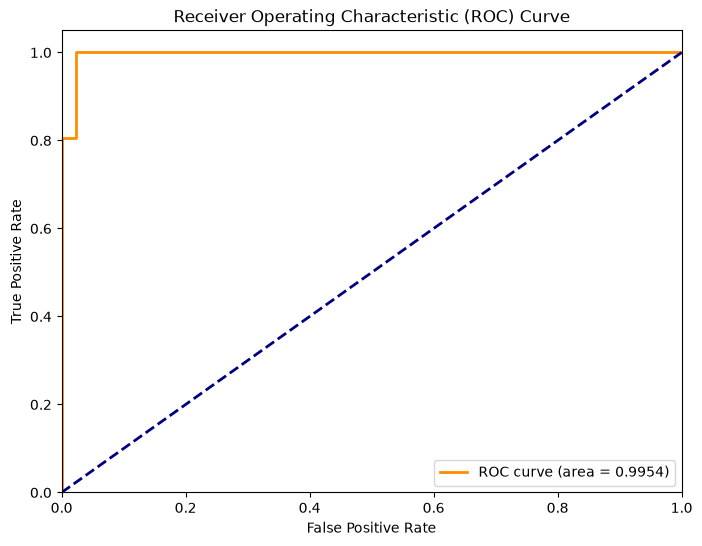

Confusion Matrix and ROC Curve saved to reports/ folder!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc
import os

# 1. Load and prepare the data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split (using the same random_state for consistency)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the winning model (Logistic Regression with C=1)
model = LogisticRegression(C=1, random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Create the reports folder if it doesn't exist
os.makedirs('reports', exist_ok=True)

# --- 2. Generate Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
plt.title('Confusion Matrix - Breast Cancer Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('reports/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 3. Generate ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('reports/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion Matrix and ROC Curve saved to reports/ folder!")

d:\Capstone Project\capstone_healthcare_ai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


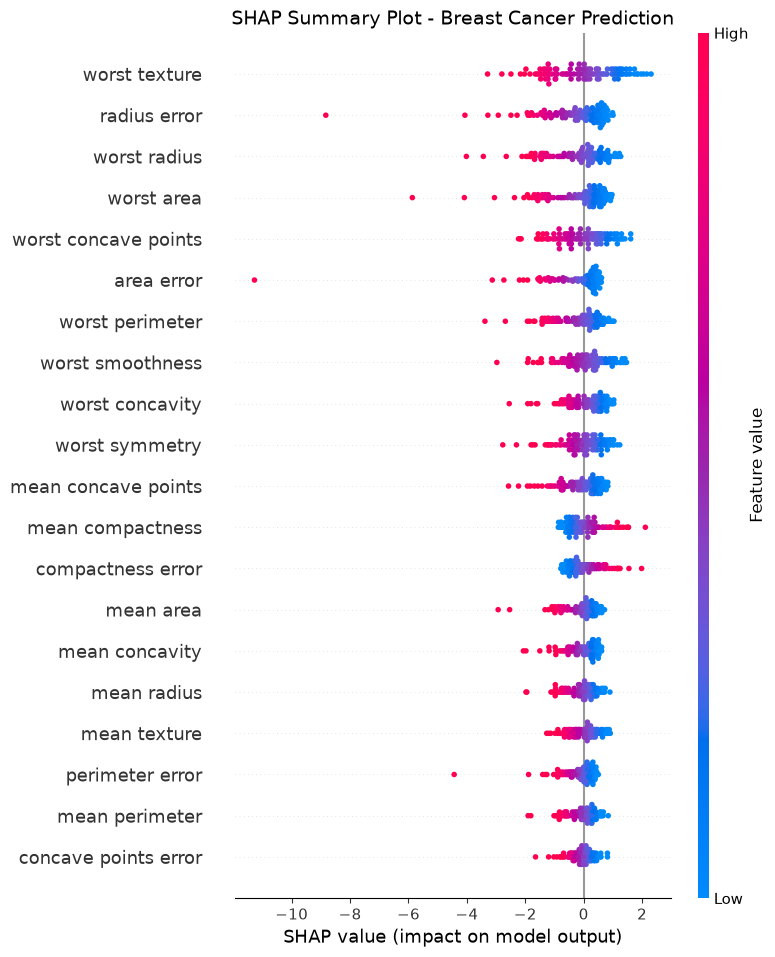

SHAP Summary Plot saved successfully to reports/shap_summary_plot.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import os

# 1. Load and prepare the data (same as before)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train the winning model
model = LogisticRegression(C=1, random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# 3. Create the SHAP Explainer and calculate SHAP values
# LinearExplainer because it is fast and exact for Logistic Regression
explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# 4. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
plt.title("SHAP Summary Plot - Breast Cancer Prediction", fontsize=14)

# 5. Save the image to my reports folder
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/shap_summary_plot.png', dpi=300, bbox_inches='tight')

# 6. Show the plot
plt.show()

print("SHAP Summary Plot saved successfully to reports/shap_summary_plot.png")